In [ ]:
#install & load packages

required_packages <- c("skimr", "dplyr", "ggplot2", "tidyr")
new_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if (length(new_packages) > 0) install.packages(new_packages)

library(skimr)
library(dplyr)
library(ggplot2)
library(tidyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
#Import & inspect the dataset

file_path <- "PRSA_Data_Aotizhongxin_20130301-20170228.csv"

import_dataset <- function(path) {
  tryCatch({
    if (!file.exists(path)) {
      stop("File not found. Please check the file path/name.")
    }
    data <- read.csv(path, stringsAsFactors = FALSE)
    if (ncol(data) == 0) {
      stop("File format is incorrect - no columns detected.")
    }
    message("File imported successfully.")
    return(data)
  },
  error = function(e) {
    message("ERROR while importing dataset: ", conditionMessage(e))
    return(NULL)
  })
}

air_data <- import_dataset(file_path)

if (!is.null(air_data)) {
  cat("\n----- Head of Dataset -----\n"); print(head(air_data))
  cat("\n----- Structure of Dataset -----\n"); str(air_data)
  cat("\n----- Dimensions -----\n")
  cat("Rows:", nrow(air_data), "\n")
  cat("Columns:", ncol(air_data), "\n")
  cat("\n----- Contains Missing Values? -----\n"); print(any(is.na(air_data)))
  cat("\n----- Total Missing Values -----\n"); print(sum(is.na(air_data)))
}

File imported successfully.




----- Head of Dataset -----
  No year month day hour PM2.5 PM10 SO2 NO2  CO O3 TEMP   PRES  DEWP RAIN  wd
1  1 2013     3   1    0     4    4   4   7 300 77 -0.7 1023.0 -18.8    0 NNW
2  2 2013     3   1    1     8    8   4   7 300 77 -1.1 1023.2 -18.2    0   N
3  3 2013     3   1    2     7    7   5  10 300 73 -1.1 1023.5 -18.2    0 NNW
4  4 2013     3   1    3     6    6  11  11 300 72 -1.4 1024.5 -19.4    0  NW
5  5 2013     3   1    4     3    3  12  12 300 72 -2.0 1025.2 -19.5    0   N
6  6 2013     3   1    5     5    5  18  18 400 66 -2.2 1025.6 -19.6    0   N
  WSPM      station
1  4.4 Aotizhongxin
2  4.7 Aotizhongxin
3  5.6 Aotizhongxin
4  3.1 Aotizhongxin
5  2.0 Aotizhongxin
6  3.7 Aotizhongxin

----- Structure of Dataset -----
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : i

In [7]:
#NA vs NULL vs NaN

temperature <- c(28, 30, NA, 32)
cat("Vector with NA:\n"); print(temperature)
cat("is.na() result:\n"); print(is.na(temperature))

missing_object <- NULL
cat("\nNULL object:\n"); print(missing_object)
cat("is.null() result:\n"); print(is.null(missing_object))

undefined_value <- 0 / 0
cat("\nNaN example (0/0):\n"); print(undefined_value)
cat("is.nan() result:\n"); print(is.nan(undefined_value))

Vector with NA:
[1] 28 30 NA 32
is.na() result:
[1] FALSE FALSE  TRUE FALSE

NULL object:
NULL
is.null() result:
[1] TRUE

NaN example (0/0):
[1] NaN
is.nan() result:
[1] TRUE


In [8]:
#Missing-value summary function

missing_summary <- function(df, variables) {
  result <- data.frame(Variable = character(), Total_Records = integer(),
                        Missing_Values = integer(), Missing_Percentage = numeric(),
                        stringsAsFactors = FALSE)

  for (var in variables) {
    if (!(var %in% names(df))) {
      warning(paste("Variable", var, "not found in dataset. Skipping."))
      next
    }
    total <- length(df[[var]])
    missing_count <- sum(is.na(df[[var]]))
    missing_pct <- round((missing_count / total) * 100, 2)

    if (missing_pct > 20) {
      warning(paste("Variable", var, "has more than 20% missing values (", missing_pct, "% )"))
    }

    result <- rbind(result, data.frame(Variable = var, Total_Records = total,
                                        Missing_Values = missing_count,
                                        Missing_Percentage = missing_pct))
  }
  return(result)
}

selected_vars <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")
summary_before <- missing_summary(air_data, selected_vars)
print(summary_before)

  Variable Total_Records Missing_Values Missing_Percentage
1    PM2.5         35064            925               2.64
2     PM10         35064            718               2.05
3      SO2         35064            935               2.67
4      NO2         35064           1023               2.92
5     TEMP         35064             20               0.06
6     WSPM         35064             14               0.04
7       wd         35064             81               0.23


In [9]:
#Invalid numerical results (pollution_ratio)

air_data$pollution_ratio <- air_data$PM2.5 / air_data$PM10

cat("NA count:", sum(is.na(air_data$pollution_ratio)), "\n")
cat("NaN count:", sum(is.nan(air_data$pollution_ratio)), "\n")
cat("Positive Infinity count:", sum(air_data$pollution_ratio == Inf, na.rm = TRUE), "\n")
cat("Negative Infinity count:", sum(air_data$pollution_ratio == -Inf, na.rm = TRUE), "\n")

air_data$pollution_ratio[is.nan(air_data$pollution_ratio)] <- NA
air_data$pollution_ratio[is.infinite(air_data$pollution_ratio)] <- NA

cat("After cleaning - remaining NA count:", sum(is.na(air_data$pollution_ratio)), "\n")

NA count: 934 
NaN count: 0 
Positive Infinity count: 0 
Negative Infinity count: 0 
After cleaning - remaining NA count: 934 


In [10]:
#Loop-based numerical imputation

numeric_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")

for (var in numeric_variables) {
  if (!(var %in% names(air_data))) {
    message("Column '", var, "' does not exist. Skipping.")
    next
  }

  missing_before <- sum(is.na(air_data[[var]]))
  med_value <- median(air_data[[var]], na.rm = TRUE)
  air_data[[var]][is.na(air_data[[var]])] <- med_value
  missing_after <- sum(is.na(air_data[[var]]))

  cat("\nVariable:", var,
      "\n  Missing before:", missing_before,
      "\n  Median used:", med_value,
      "\n  Missing after:", missing_after, "\n")
}


Variable: PM2.5 
  Missing before: 925 
  Median used: 58 
  Missing after: 0 

Variable: PM10 
  Missing before: 718 
  Median used: 87 
  Missing after: 0 

Variable: SO2 
  Missing before: 935 
  Median used: 9 
  Missing after: 0 

Variable: NO2 
  Missing before: 1023 
  Median used: 53 
  Missing after: 0 

Variable: TEMP 
  Missing before: 20 
  Median used: 14.5 
  Missing after: 0 

Variable: WSPM 
  Missing before: 14 
  Median used: 1.4 
  Missing after: 0 


In [12]:
#Categorical missing values (wd)

calculate_mode <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA)
  freq_table <- table(x)
  names(freq_table)[which.max(freq_table)]
}

wd_missing_before <- sum(is.na(air_data$wd))
wd_mode <- calculate_mode(air_data$wd)
air_data$wd[is.na(air_data$wd)] <- wd_mode
wd_missing_after <- sum(is.na(air_data$wd))

cat("Mode of wd:", wd_mode, "\n")
cat("Missing values before:", wd_missing_before, "\n")
cat("Missing values after:", wd_missing_after, "\n")


Mode of wd: NE 
Missing values before: 81 
Missing values after: 0 


In [14]:
#clean_variable() with error handling

clean_variable <- function(df, var_name) {
  tryCatch({
    if (!(var_name %in% names(df))) {
      stop(paste("Variable '", var_name, "' does not exist in the dataset.", sep = ""))
    }
    variable <- df[[var_name]]

    if (!is.numeric(variable)) {
      stop(paste("Variable '", var_name, "' is categorical, not numerical.", sep = ""))
    }
    if (all(is.na(variable))) {
      stop(paste("Variable '", var_name, "' contains only missing values.", sep = ""))
    }

    med_value <- suppressWarnings(median(variable, na.rm = TRUE))
    if (is.na(med_value)) {
      stop(paste("Median could not be calculated for '", var_name, "'.", sep = ""))
    }

    variable[is.na(variable)] <- med_value
    message("Variable '", var_name, "' cleaned successfully.")
    return(variable)
  },
  error = function(e) {
    message("clean_variable() ERROR: ", conditionMessage(e))
    return(NULL)
  })
}

# Demonstrations
cleaned_temp <- clean_variable(air_data, "TEMP")
clean_variable(air_data, "NON_EXISTENT_VAR")
clean_variable(air_data, "wd")


Variable 'TEMP' cleaned successfully.

clean_variable() ERROR: Variable 'NON_EXISTENT_VAR' does not exist in the dataset.



NULL

clean_variable() ERROR: Variable 'wd' is categorical, not numerical.



NULL

In [15]:
#Before/after comparison table

summary_after <- missing_summary(air_data, selected_vars)

comparison_table <- data.frame(
  Variable = summary_before$Variable,
  Missing_Before = summary_before$Missing_Values,
  Missing_After = summary_after$Missing_Values
)
comparison_table$Values_Replaced <- comparison_table$Missing_Before - comparison_table$Missing_After

print(comparison_table)

if (all(comparison_table$Missing_After == 0)) {
  cat("\nAll missing values in the selected variables were successfully handled.\n")
} else {
  cat("\nSome missing values remain unhandled - review those variables.\n")
}

  Variable Missing_Before Missing_After Values_Replaced
1    PM2.5            925             0             925
2     PM10            718             0             718
3      SO2            935             0             935
4      NO2           1023             0            1023
5     TEMP             20             0              20
6     WSPM             14             0              14
7       wd             81             0              81

All missing values in the selected variables were successfully handled.


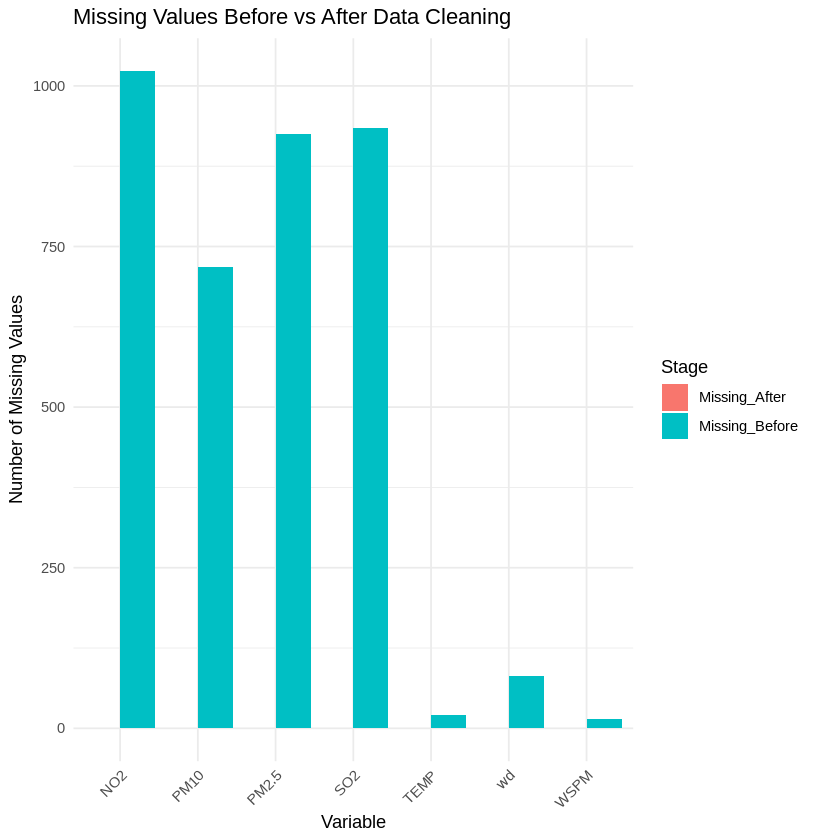

In [16]:
#Visualization

plot_data <- comparison_table %>%
  select(Variable, Missing_Before, Missing_After) %>%
  pivot_longer(cols = c(Missing_Before, Missing_After),
               names_to = "Stage", values_to = "Missing_Count")

p <- ggplot(plot_data, aes(x = Variable, y = Missing_Count, fill = Stage)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Missing Values Before vs After Data Cleaning",
       x = "Variable", y = "Number of Missing Values", fill = "Stage") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p)
ggsave("missing_values_comparison.png", plot = p, width = 8, height = 5)


In [17]:
#Export Clean dataset

write.csv(air_data, "cleaned_air_quality_data.csv", row.names = FALSE)
cat("Cleaned dataset exported as 'cleaned_air_quality_data.csv'\n")

Cleaned dataset exported as 'cleaned_air_quality_data.csv'
